# Exploratory Data Analysis (EDA) using Python Notebooks

In [1]:
from google.colab import auth
auth.authenticate_user()

In [2]:
from google.cloud import bigquery
import pandas as pd

In [3]:
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "ken-k-capstone"
client = bigquery.Client(project=PROJECT_ID)

In [4]:
query = """
SELECT *
FROM `ken-k-capstone.kens_capstone_data.taxi_sample`
"""
df = client.query(query).to_dataframe()

df.head()

,unique_key,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,extras,trip_total,payment_type,company,pickup_latitude,pickup_longitude,pickup_location,dropoff_latitude,dropoff_longitude,dropoff_location
0,9b3fd312f529894d04ca5e6f22c6e793eefdf0de,d744f003d8f56f6a8b53b97c0589575fa9a975e9d12f66...,2013-06-16 15:00:00+00:00,2013-06-16 15:00:00+00:00,0,0.0,<NA>,<NA>,<NA>,<NA>,...,0.0,49.55,Credit Card,Chicago Elite Cab Corp.,NaN,NaN,None,NaN,NaN,None
1,21158fe4a91b731ee9097ee1e85327a218a02e38,49c7419cb833c4208dbc10ac896577053817af7ced62eb...,2013-05-06 21:00:00+00:00,2013-05-06 21:00:00+00:00,<NA>,0.0,<NA>,<NA>,<NA>,<NA>,...,0.0,15.45,Credit Card,Chicago Elite Cab Corp.,NaN,NaN,None,NaN,NaN,None
2,49651f101911e48916e4c0a4bcf86bd370fdc4ff,c6006a1a63884079530d6eb197850de81e4b867fc0f96a...,2013-05-08 19:00:00+00:00,2013-05-08 18:45:00+00:00,<NA>,0.0,<NA>,<NA>,<NA>,<NA>,...,0.0,29.81,Credit Card,Chicago Elite Cab Corp.,NaN,NaN,None,NaN,NaN,None
3,1df61a8c24a297508241bf2d1fb6c370ff9751c0,30aadbeb94781e6be1c5302acc6d4bfa2c40b6b06e09eb...,2013-05-08 13:45:00+00:00,2013-05-08 13:45:00+00:00,0,0.0,<NA>,<NA>,<NA>,<NA>,...,0.0,41.25,Credit Card,Taxi Affiliation Services,NaN,NaN,None,NaN,NaN,None
4,5cd103028678c74a80b8c0b7771123ac7ecdeff4,871748cf55a0d132c28d2fdb03bc9e2bb20f283ec11120...,2013-05-17 09:00:00+00:00,2013-05-17 09:00:00+00:00,<NA>,0.0,<NA>,<NA>,<NA>,<NA>,...,0.0,33.18,Credit Card,Chicago Elite Cab Corp.,NaN,NaN,None,NaN,NaN,None


In [5]:
df.shape

(1000000, 23)

#### Initial informational exploration

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 23 columns):
 #   Column                  Non-Null Count    Dtype              
---  ------                  --------------    -----              
 0   unique_key              1000000 non-null  object             
 1   taxi_id                 1000000 non-null  object             
 2   trip_start_timestamp    1000000 non-null  datetime64[us, UTC]
 3   trip_end_timestamp      999923 non-null   datetime64[us, UTC]
 4   trip_seconds            993174 non-null   Int64              
 5   trip_miles              999985 non-null   float64            
 6   pickup_census_tract     653884 non-null   Int64              
 7   dropoff_census_tract    648152 non-null   Int64              
 8   pickup_community_area   907149 non-null   Int64              
 9   dropoff_community_area  883710 non-null   Int64              
 10  fare                    999904 non-null   float64            
 11  tips        

In [7]:
df[["fare", "tips", "tolls", "extras", "trip_total", "trip_seconds", "trip_miles"]].describe()

,fare,tips,tolls,extras,trip_total,trip_seconds,trip_miles
count,999904.000000,999904.000000,833515.000000,999904.000000,999904.000000,993174.0,999985.000000
mean,13.729247,1.507739,0.006517,1.035395,16.332632,814.742216,3.442988
std,42.445004,2.852821,0.569425,17.964530,47.177241,1213.972167,11.293162
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,6.000000,0.000000,0.000000,0.000000,7.050000,336.0,0.200000
50%,8.250000,0.000000,0.000000,0.000000,9.850000,551.0,1.200000
75%,14.250000,2.000000,0.000000,1.000000,16.350000,963.0,3.200000
max,9001.340000,500.000000,300.000000,7777.770000,9051.340000,86376.0,2190.000000


In [8]:
df.describe()

,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare,tips,tolls,extras,trip_total,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
count,993174.0,999985.000000,653884.0,648152.0,907149.0,883710.0,999904.000000,999904.000000,833515.000000,999904.000000,999904.000000,907283.000000,907283.000000,886386.000000,886386.000000
mean,814.742216,3.442988,17031379652.565981,17031361790.501759,24.409569,22.082286,13.729247,1.507739,0.006517,1.035395,16.332632,41.901231,-87.662063,41.900581,-87.655152
std,1213.972167,11.293162,345356.775382,334841.213511,20.560276,18.175408,42.445004,2.852821,0.569425,17.964530,47.177241,0.040996,0.076483,0.040484,0.060881
min,0.0,0.000000,17031010100.0,17031010100.0,1.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,41.660136,-87.913625,41.660136,-87.913625
25%,336.0,0.200000,17031081403.0,17031081402.0,8.0,8.0,6.000000,0.000000,0.000000,0.000000,7.050000,41.880994,-87.655998,41.880994,-87.655998
50%,551.0,1.200000,17031281900.0,17031280100.0,24.0,22.0,8.250000,0.000000,0.000000,0.000000,9.850000,41.892508,-87.632746,41.892508,-87.633308
75%,963.0,3.200000,17031839100.0,17031833000.0,32.0,32.0,14.250000,2.000000,0.000000,1.000000,16.350000,41.914616,-87.626211,41.921273,-87.626211
max,86376.0,2190.000000,17031980100.0,17031980100.0,77.0,77.0,9001.340000,500.000000,300.000000,7777.770000,9051.340000,42.021224,-87.534903,42.021224,-87.534903


In [9]:
df.columns

Index(['unique_key', 'taxi_id', 'trip_start_timestamp', 'trip_end_timestamp',
       'trip_seconds', 'trip_miles', 'pickup_census_tract',
       'dropoff_census_tract', 'pickup_community_area',
       'dropoff_community_area', 'fare', 'tips', 'tolls', 'extras',
       'trip_total', 'payment_type', 'company', 'pickup_latitude',
       'pickup_longitude', 'pickup_location', 'dropoff_latitude',
       'dropoff_longitude', 'dropoff_location'],
      dtype='object')

In [10]:
df.isna().sum().sort_values(ascending=False)

,0
dropoff_census_tract,351848
pickup_census_tract,346116
tolls,166485
company,145834
dropoff_community_area,116290
dropoff_longitude,113614
dropoff_latitude,113614
dropoff_location,113614
pickup_community_area,92851
pickup_latitude,92717


###### Initial exploration indicates a concerning presence of null values particularly in the pickup and dropoff columns. Approximately 35% of the census tracts are null in both pickup and dropoff, 11.5% of the remainder of dropoff columns are null, and 9.3% of the pickups are null.

###### There's also something peculiar going on with the fares. Someone racked up a *huge* bill that's likely not throwing the average off very much due to having a million observations, however it's immediately unusual in its aberration. It's also potentially throwing off the other metrics if it's as long as a trip as the fare would suggest.

# EDA

In [11]:
missing = (
    df.isnull()
       .sum()
       .to_frame("Missing")
)

missing["Pct_Missing"] = round(
    missing["Missing"] / len(df) * 100, 2
)

missing.sort_values(
    "Pct_Missing",
    ascending=False
).head(15)

,Missing,Pct_Missing
dropoff_census_tract,351848,35.18
pickup_census_tract,346116,34.61
tolls,166485,16.65
company,145834,14.58
dropoff_community_area,116290,11.63
dropoff_longitude,113614,11.36
dropoff_latitude,113614,11.36
dropoff_location,113614,11.36
pickup_community_area,92851,9.29
pickup_latitude,92717,9.27


###### Now, with the outliers from earlier, I have the issue of seeing how many of them there are of a similar extreme.

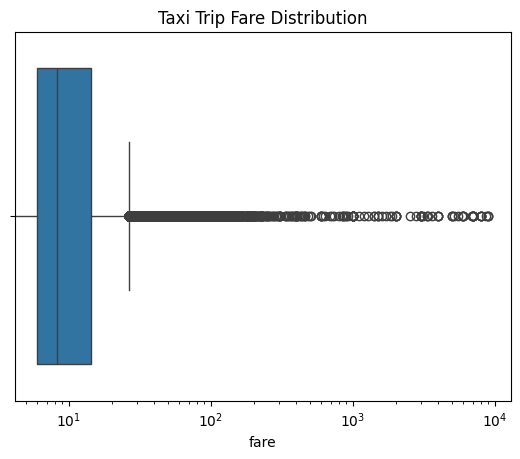

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=df["fare"])
plt.xscale('log')
plt.title("Taxi Trip Fare Distribution")
plt.show()

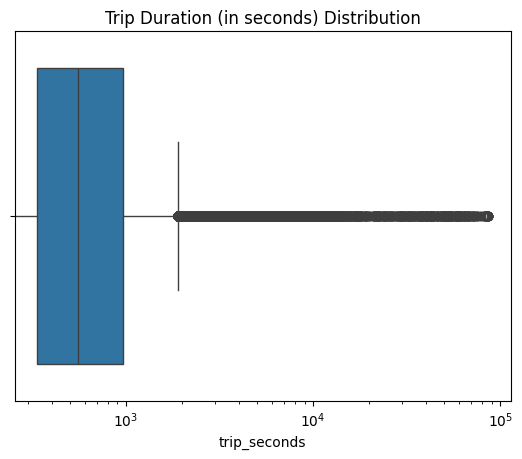

In [13]:
sns.boxplot(x=df["trip_seconds"])
plt.xscale('log')
plt.title("Trip Duration (in seconds) Distribution")
plt.show()

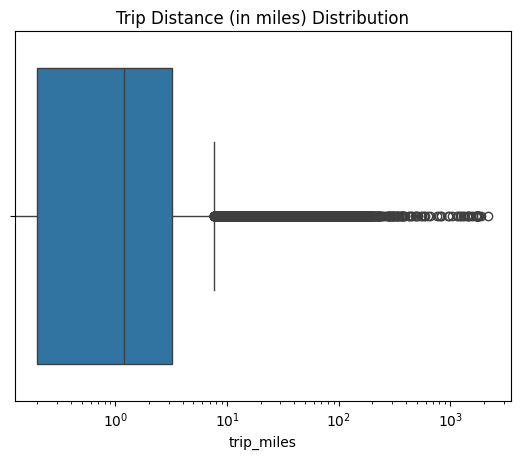

In [14]:
sns.boxplot(x=df["trip_miles"])
plt.xscale('log')
plt.title("Trip Distance (in miles) Distribution")
plt.show()

###### Upon viewing a logarithmically scaled visual of the data, there does seem to be a more-normal range for the duration when ignoring the worst-offending outliers. Now it's evident that there's something odd going on that I will further explore in the visualization stage via Tableau.

In [15]:
df["fare"].describe()

,fare
count,999904.000000
mean,13.729247
std,42.445004
min,0.000000
25%,6.000000
50%,8.250000
75%,14.250000
max,9001.340000


In [16]:
import statistics as stats
import numpy as np
print("Mean of Fare: $", round(np.nanmean(df['fare']), 2))
print("Median of Fare: $", stats.median(df['fare']))
print("Mode of Fare: $", stats.mode(df['fare']))

Mean of Fare: $ 13.73
Median of Fare: $ 14.05
Mode of Fare: $ 3.25


In [17]:
df['fare'].value_counts().head(20)

,count
fare,
3.25,30784
6.25,29644
5.25,26894
7.25,24325
8.25,18795
6.00,17986
5.75,17040
6.50,17003
5.50,16757


In [18]:
df['fare'].value_counts().tail(20)

,count
fare,
26.82,1
30.73,1
13.09,1
12.33,1
18.18,1
89.10,1
404.06,1
45.35,1
13.34,1


###### It's readily apparent that the outliers I noticed before weren't unique cases. This indicates there is some sort of pattern for those egregiously large variables.

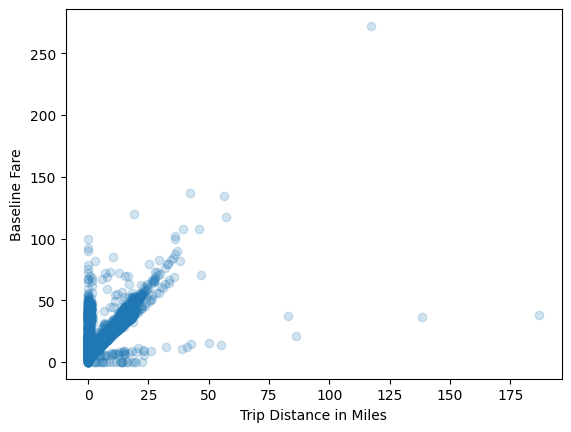

In [19]:
sample = df.sample(10000)

plt.scatter(
    sample["trip_miles"],
    sample["fare"],
    alpha=.2
)

plt.xlabel("Trip Distance in Miles")
plt.ylabel("Baseline Fare")

plt.show()

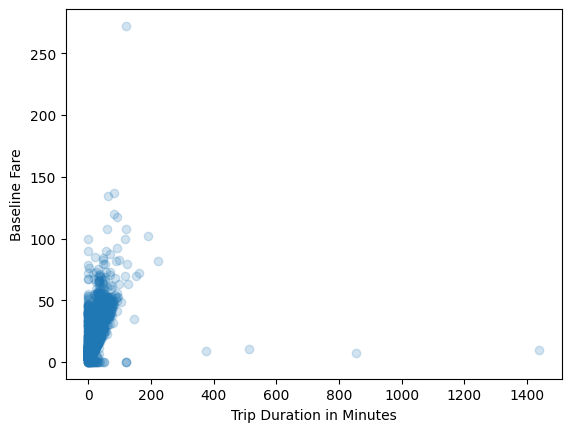

In [20]:
plt.scatter(
    sample["trip_seconds"] / 60,
    sample["fare"],
    alpha=.2
)

plt.xlabel("Trip Duration in Minutes")
plt.ylabel("Baseline Fare")

plt.show()

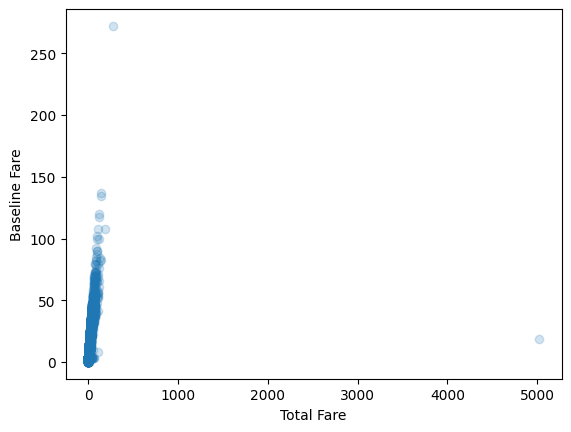

In [21]:
plt.scatter(
    sample["trip_total"],
    sample["fare"],
    alpha=.2
)

plt.xlabel("Total Fare")
plt.ylabel("Baseline Fare")

plt.show()

In [22]:
missing.sort_values(
    "Pct_Missing",
    ascending=False
)

,Missing,Pct_Missing
dropoff_census_tract,351848,35.18
pickup_census_tract,346116,34.61
tolls,166485,16.65
company,145834,14.58
dropoff_community_area,116290,11.63
dropoff_longitude,113614,11.36
dropoff_latitude,113614,11.36
dropoff_location,113614,11.36
pickup_community_area,92851,9.29
pickup_latitude,92717,9.27


## Cleaning up nulls

In [23]:
df_clean = df.copy()

In [24]:
drop_cols = [
    'dropoff_census_tract',
    'pickup_census_tract'
]

df_clean = df_clean.drop(columns=drop_cols)

In [25]:
df_clean['company'] = (
    df_clean['company']
    .astype('object')
    .fillna('Unknown')
)

In [46]:
pickup_loc_cols = [
    'pickup_latitude',
    'pickup_longitude'
]
dropoff_loc_cols = [
    'dropoff_latitude',
    'dropoff_longitude'
]

In [50]:
pickup_area_cols = [
    'pickup_community_area',
    'pickup_location'
]
dropoff_area_cols = [
    'dropoff_community_area',
    'dropoff_location'
]

for col in pickup_area_cols:
  df_clean[col] = df_clean[col].fillna(0)
for col in dropoff_area_cols:
  df_clean[col] = df_clean[col].fillna(0)

In [40]:
df_clean['trip_seconds'] = (
    df_clean['trip_seconds']
    .fillna(df_clean['trip_seconds'].median())
)

In [41]:
df_clean['trip_end_timestamp'] = (
    df_clean['trip_end_timestamp']
    .fillna(df_clean['trip_start_timestamp'])
)

In [37]:
df_clean[['fare', 'tolls', 'extras', 'tips', 'trip_total', 'trip_seconds', 'trip_miles']] = df_clean[['fare', 'tolls', 'extras', 'tips', 'trip_total', 'trip_seconds', 'trip_miles']].fillna(0)

In [51]:
clean_missing = (
    df_clean.isnull()
       .sum()
       .to_frame("Missing")
)

clean_missing["Pct_Missing"] = round(
    missing["Missing"] / len(df) * 100, 2
)

clean_missing.sort_values(
    "Pct_Missing",
    ascending=False
).head(15)

,Missing,Pct_Missing
tolls,0,16.65
company,0,14.58
dropoff_community_area,0,11.63
dropoff_location,0,11.36
dropoff_latitude,0,11.36
dropoff_longitude,0,11.36
pickup_community_area,0,9.29
pickup_location,0,9.27
pickup_latitude,0,9.27
pickup_longitude,0,9.27


In [52]:
missing_after = (
    df_clean
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_after.head(20)

,0
unique_key,0
taxi_id,0
trip_start_timestamp,0
trip_end_timestamp,0
trip_seconds,0
trip_miles,0
pickup_community_area,0
dropoff_community_area,0
fare,0
tips,0


In [53]:
from pandas_gbq import to_gbq

to_gbq(
    df_clean,
    destination_table='kens_capstone_data.taxi_cleaned',
    project_id='ken-k-capstone',
    if_exists='replace'
)

/usr/local/lib/python3.12/dist-packages/pandas_gbq/schema/pandas_to_bigquery.py:159: UserWarning: Could not determine the type of columns: pickup_location, dropoff_location
  warnings.warn(msg)
100%|██████████| 1/1 [00:00<00:00, 10106.76it/s]
